## ==========================================
# Part 1: Data Reading and Preparation
# ==========================================

In [1]:
import os
import csv
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage

# Path to the directory containing raw images
img_path = "C:\\Users\\Ehadish\\New folder\\data"    

images = []              # List to store image objects
img_names = []           # List to store image filenames

# Load images from the specified directory
for file in os.listdir(img_path):
    if file.lower().endswith((".jpg", ".png", ".jpeg")):
        path = os.path.join(img_path, file)
        img = Image.open(path)
        images.append(img)
        img_names.append(file)

print("Total images loaded:", len(images))

Total images loaded: 90


In [2]:
# Load Metadata from CSV file
csv_path = "C:\\Users\\Ehadish\\New folder\\data.csv"
labels = {}     # Maps filenames to labels, e.g., labels["1.jpg"] = 0

with open(csv_path, "r") as file:
    reader = csv.reader(file)
    next(reader)     # Skip the header row
    for row in reader:
        name = row[0] + ".jpg"     # Convert ID to filename, e.g., 1 -> 1.jpg
        color = int(row[1])        # Numeric color label
        labels[name] = color
   
print("Total labels loaded:", len(labels))

Total labels loaded: 90


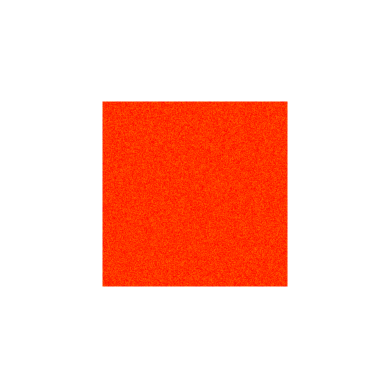

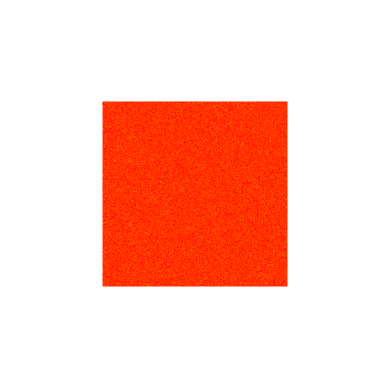

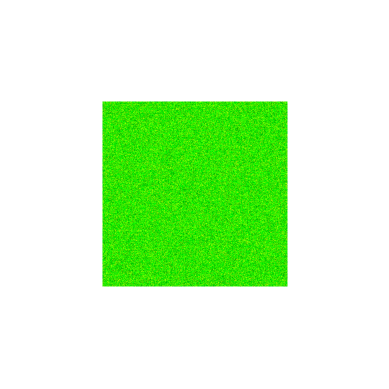

In [3]:
# Display 3 randomly selected images to verify loading integrity
for i in range(3):
    rnd = random.choice(img_names)
    img = Image.open(os.path.join(img_path, rnd))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [4]:
# Display current label mapping
print("Label mappings:", labels)

Label mappings: {'1.jpg': 0, '2.jpg': 0, '3.jpg': 0, '4.jpg': 0, '5.jpg': 0, '6.jpg': 0, '7.jpg': 2, '8.jpg': 2, '9.jpg': 1, '10.jpg': 2, '11.jpg': 0, '12.jpg': 1, '13.jpg': 1, '14.jpg': 2, '15.jpg': 1, '16.jpg': 2, '17.jpg': 0, '18.jpg': 1, '19.jpg': 0, '20.jpg': 0, '21.jpg': 0, '22.jpg': 1, '23.jpg': 0, '24.jpg': 2, '25.jpg': 0, '26.jpg': 1, '27.jpg': 0, '28.jpg': 1, '29.jpg': 2, '30.jpg': 2, '31.jpg': 0, '32.jpg': 2, '33.jpg': 1, '34.jpg': 1, '35.jpg': 2, '36.jpg': 1, '37.jpg': 1, '38.jpg': 2, '39.jpg': 2, '40.jpg': 1, '41.jpg': 2, '42.jpg': 0, '43.jpg': 1, '44.jpg': 0, '45.jpg': 0, '46.jpg': 2, '47.jpg': 2, '48.jpg': 2, '49.jpg': 1, '50.jpg': 1, '51.jpg': 2, '52.jpg': 0, '53.jpg': 2, '54.jpg': 0, '55.jpg': 2, '56.jpg': 0, '57.jpg': 0, '58.jpg': 2, '59.jpg': 0, '60.jpg': 1, '61.jpg': 2, '62.jpg': 0, '63.jpg': 0, '64.jpg': 0, '65.jpg': 1, '66.jpg': 2, '67.jpg': 1, '68.jpg': 1, '69.jpg': 1, '70.jpg': 1, '71.jpg': 0, '72.jpg': 1, '73.jpg': 1, '74.jpg': 1, '75.jpg': 2, '76.jpg': 2, '77.

## ==========================================
# Part 2: Image Processing
# ==========================================

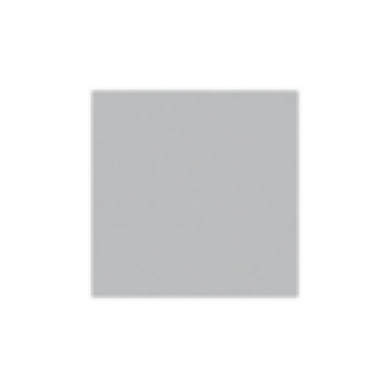

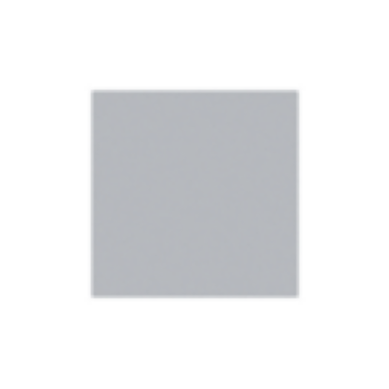

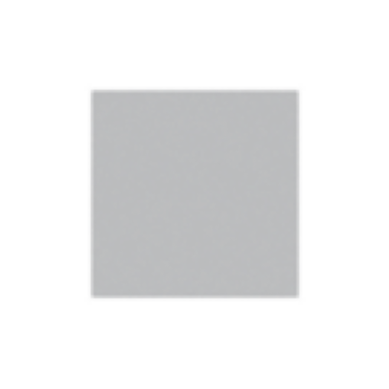

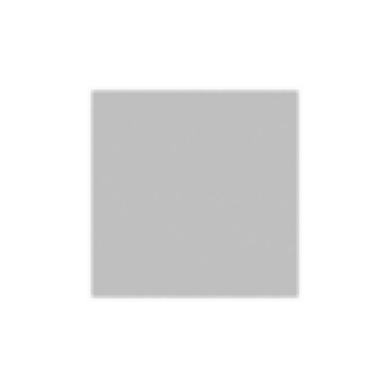

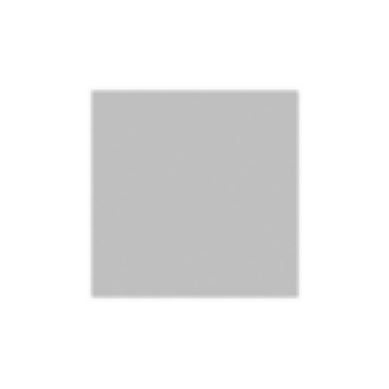

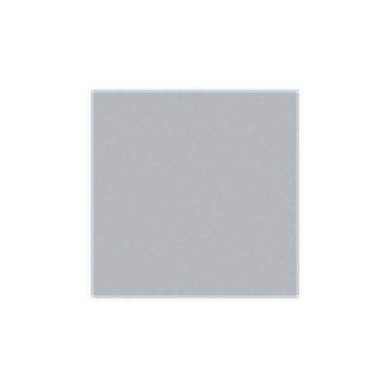

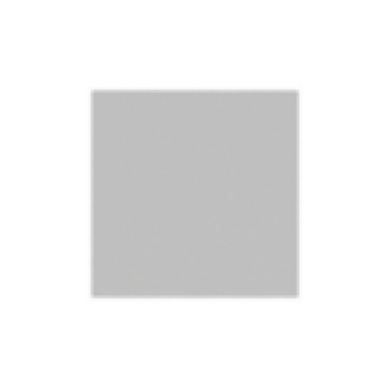

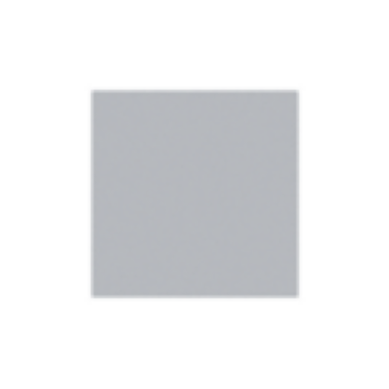

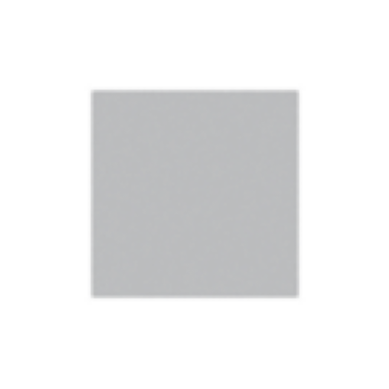

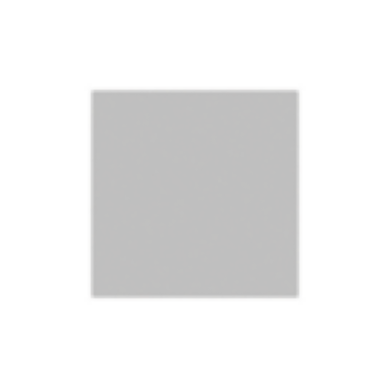

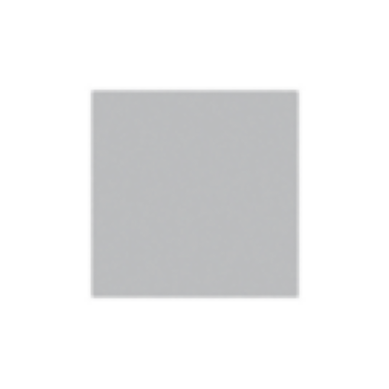

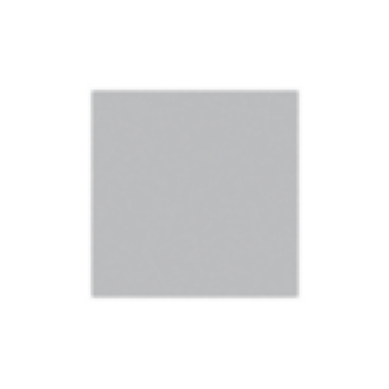

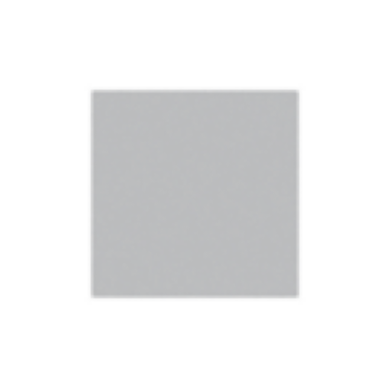

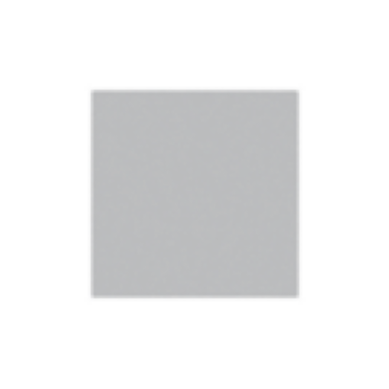

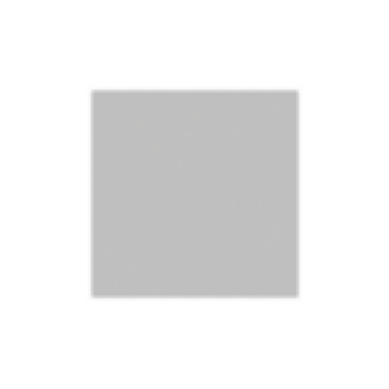

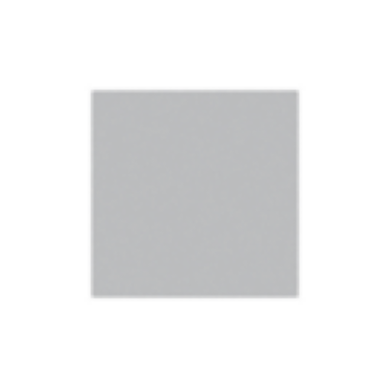

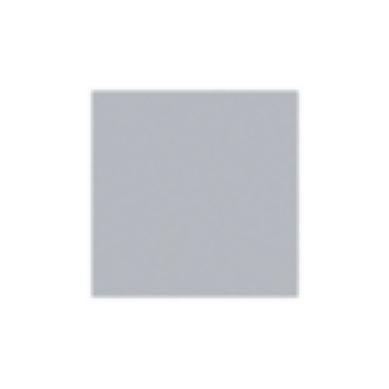

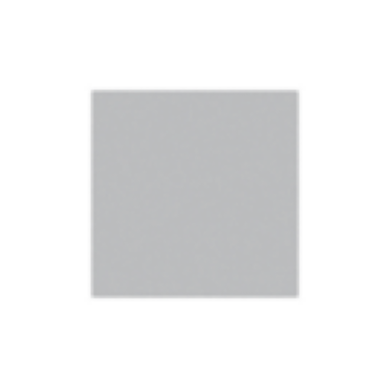

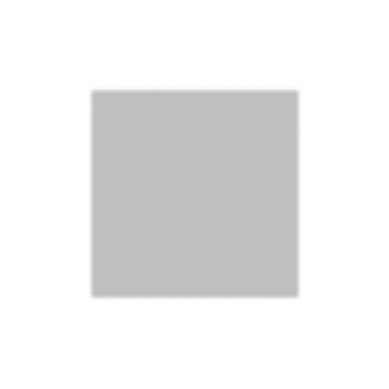

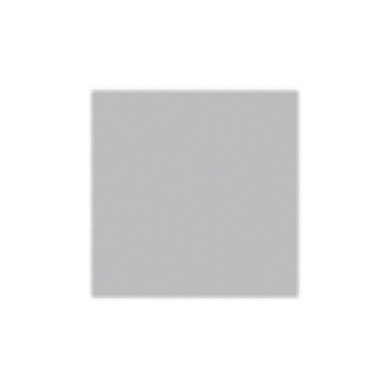

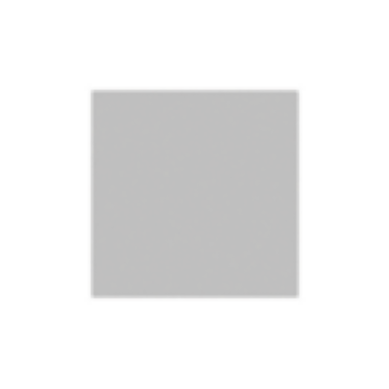

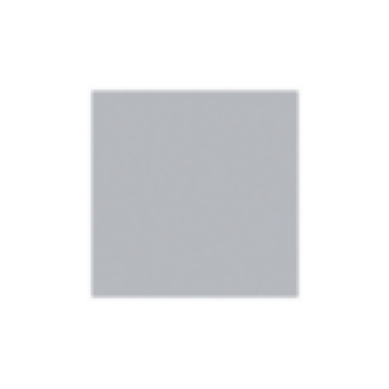

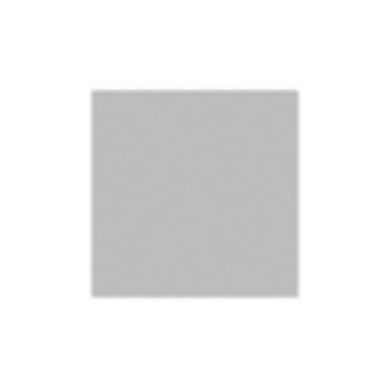

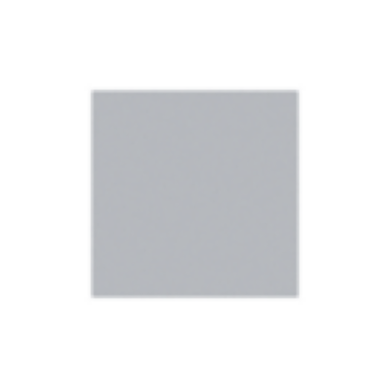

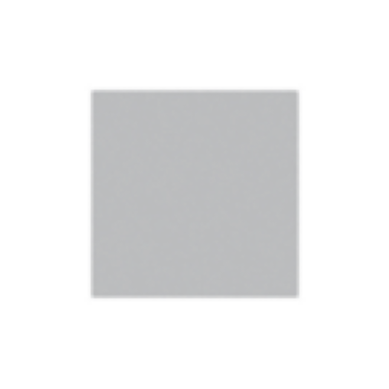

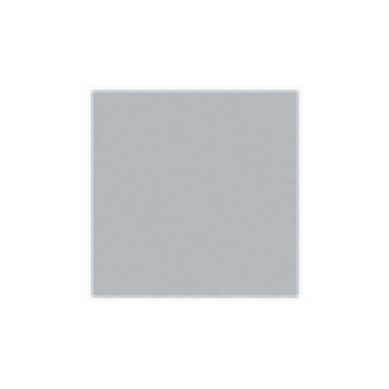

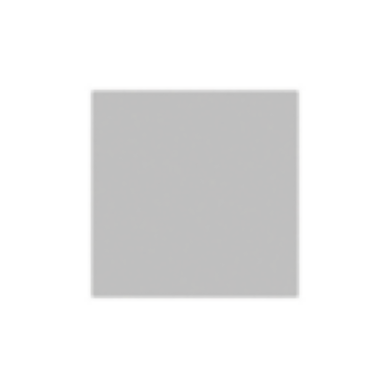

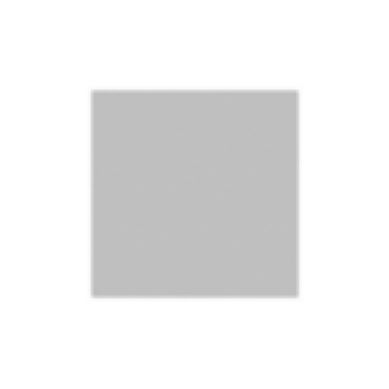

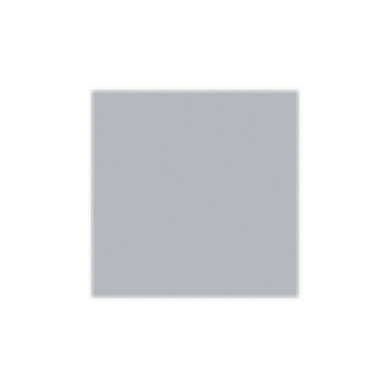

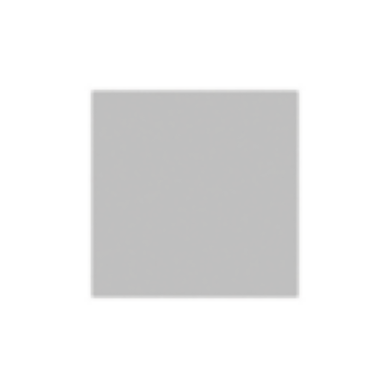

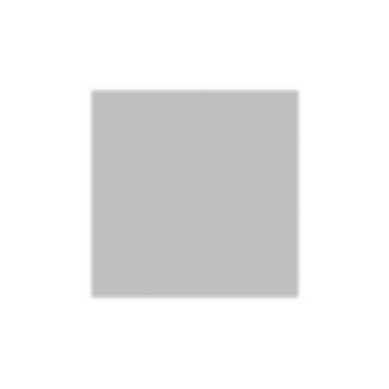

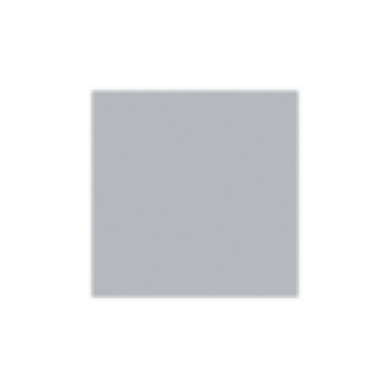

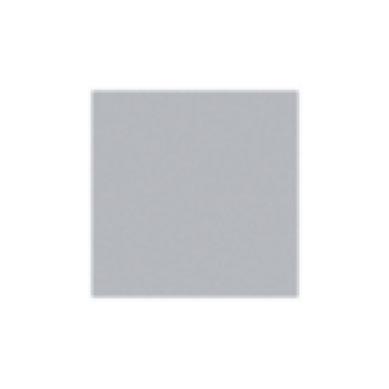

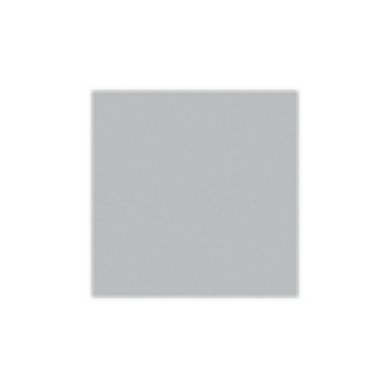

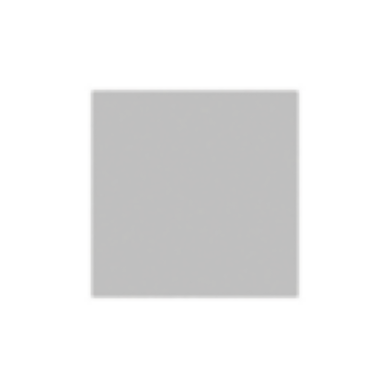

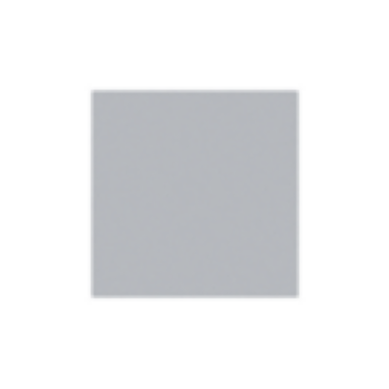

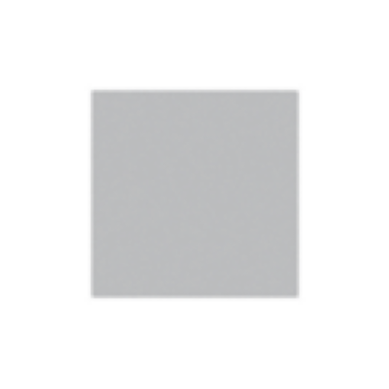

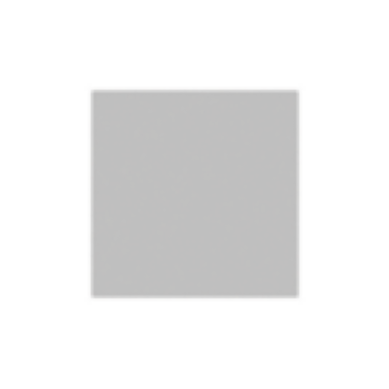

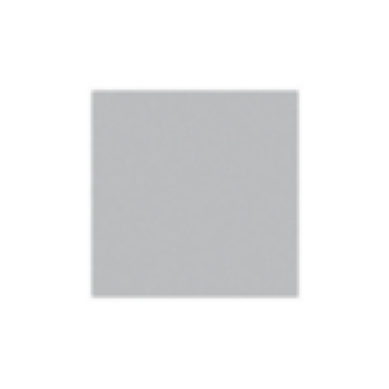

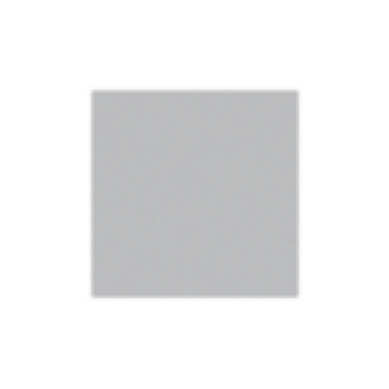

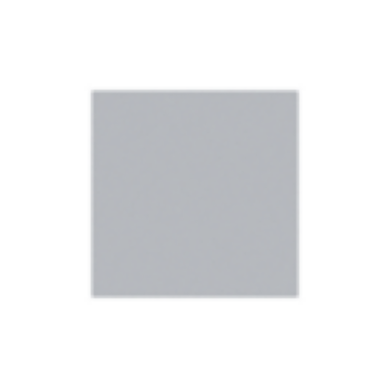

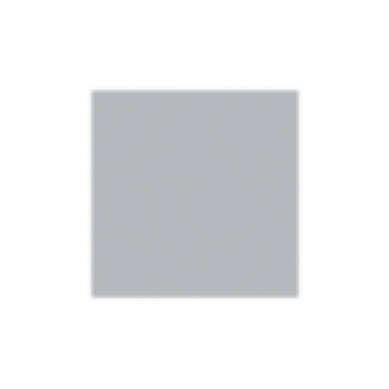

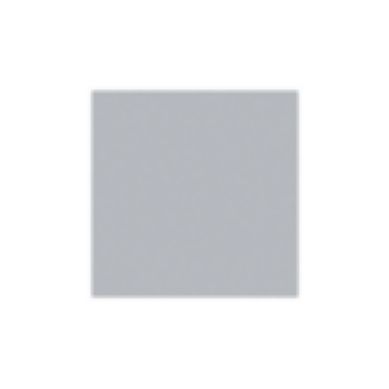

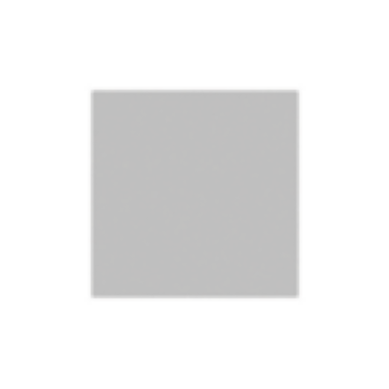

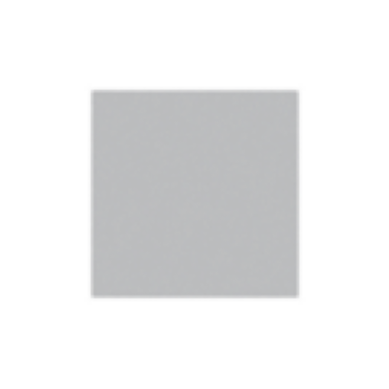

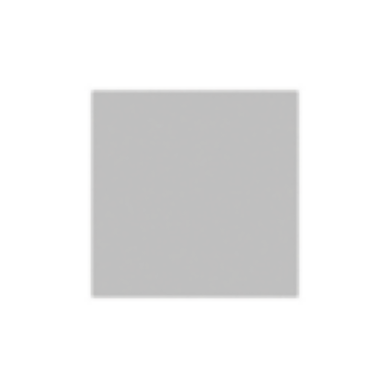

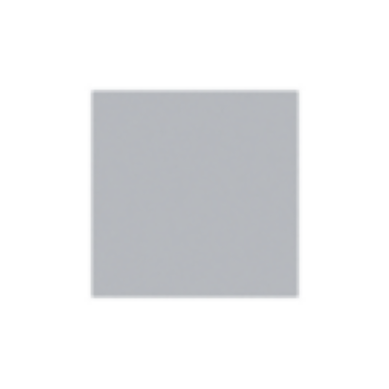

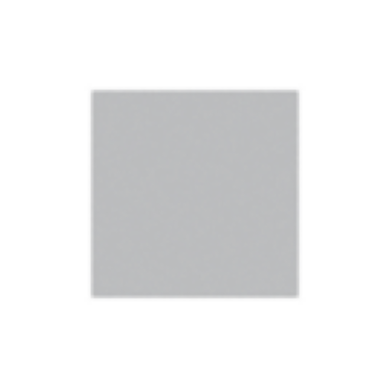

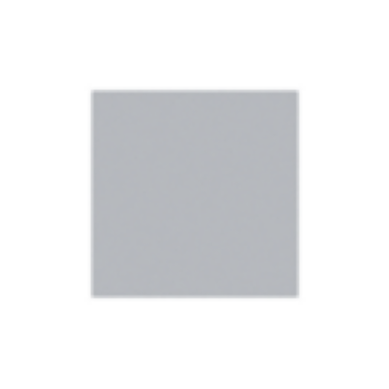

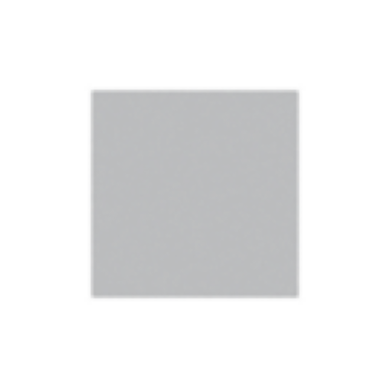

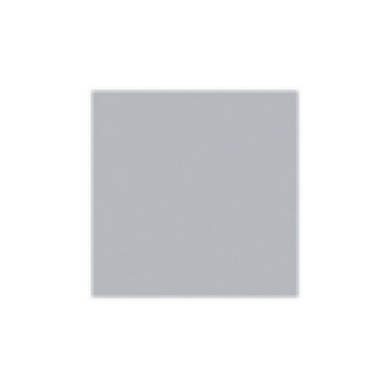

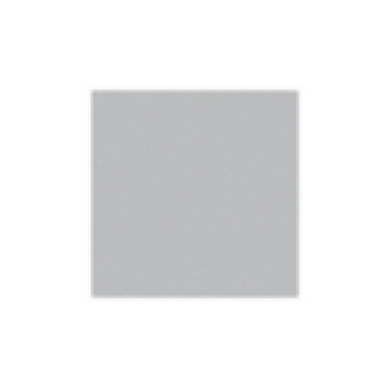

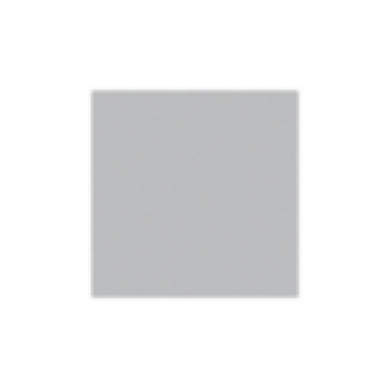

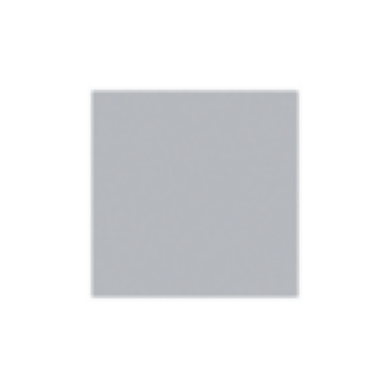

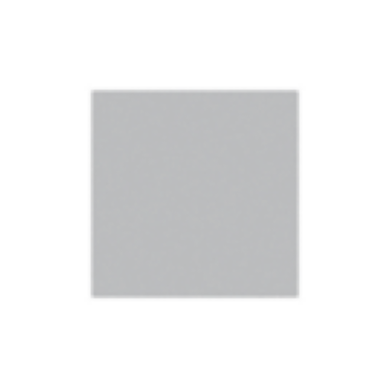

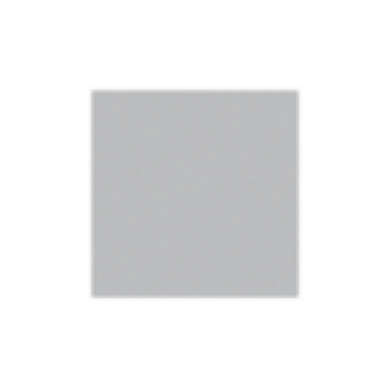

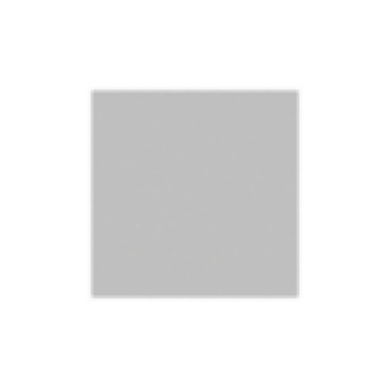

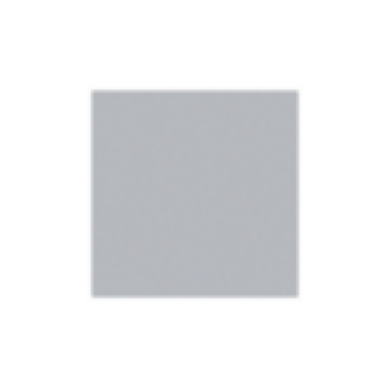

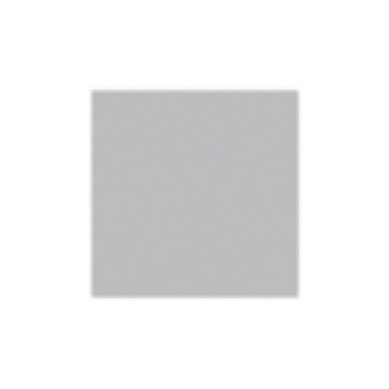

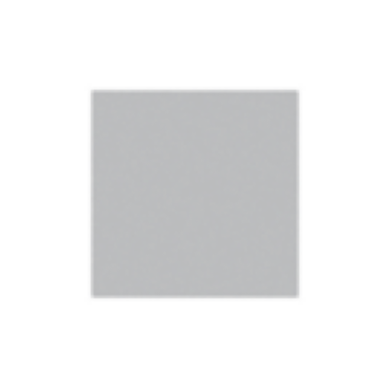

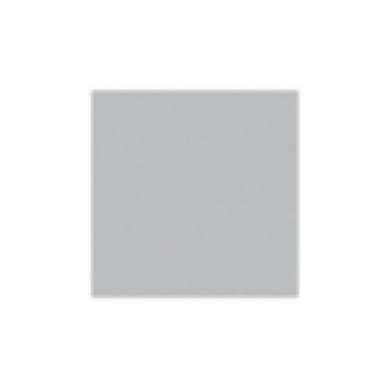

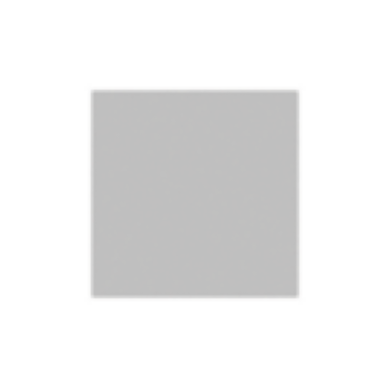

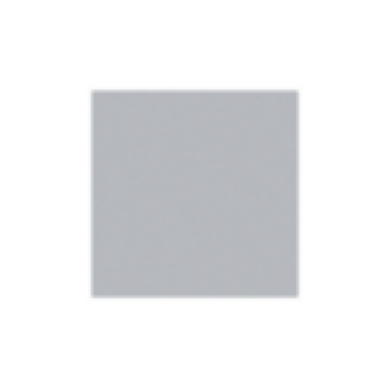

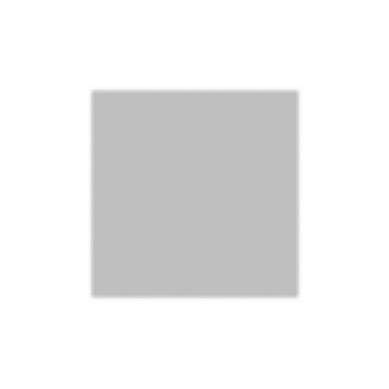

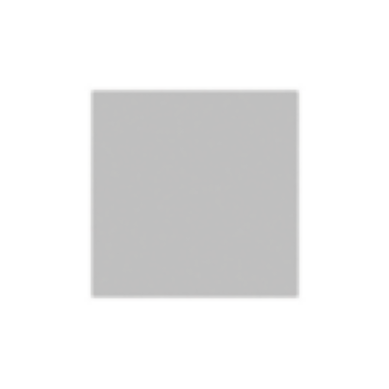

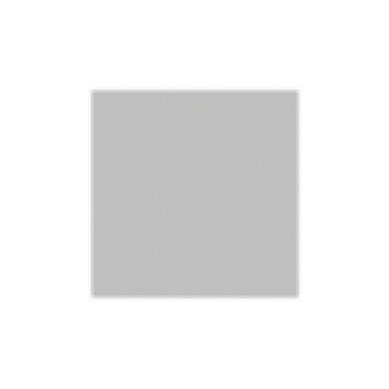

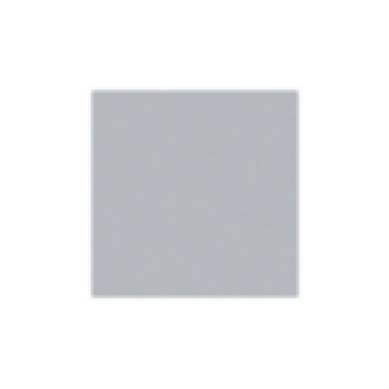

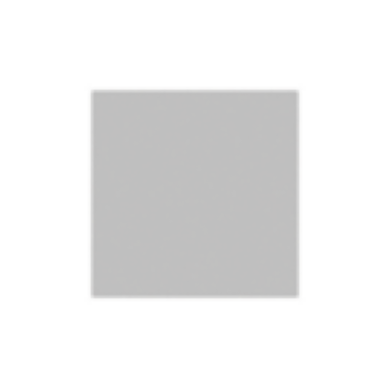

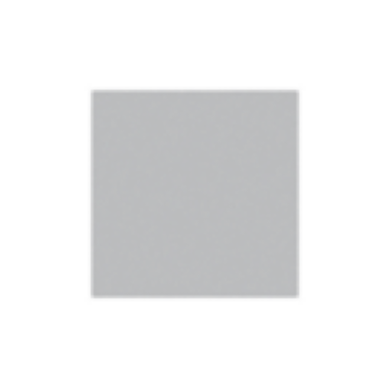

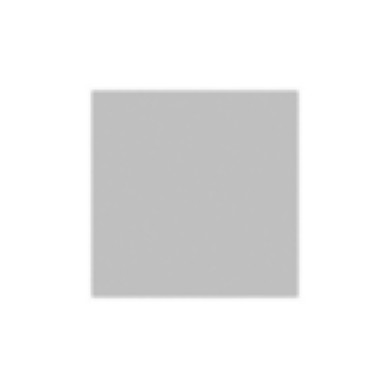

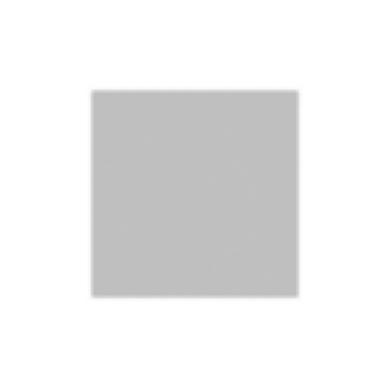

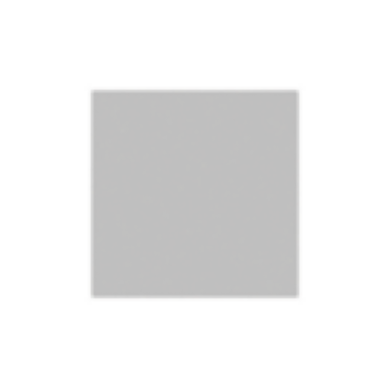

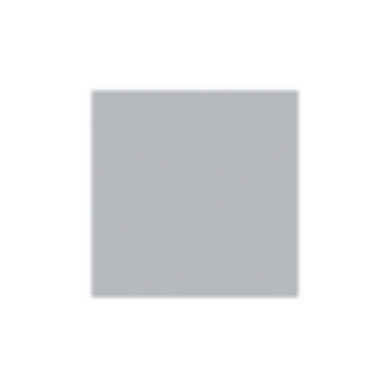

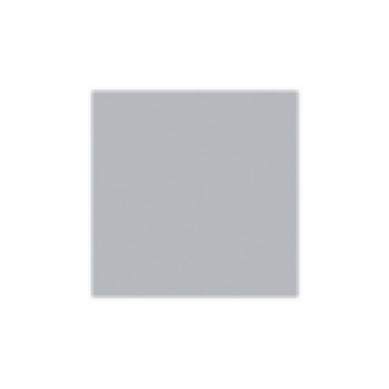

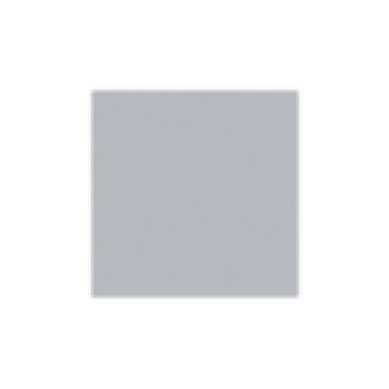

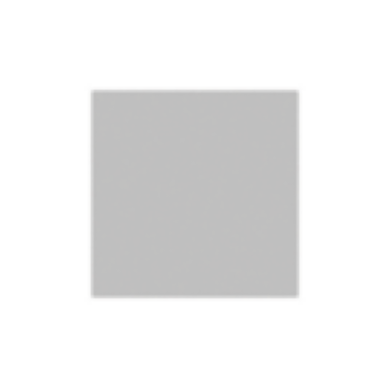

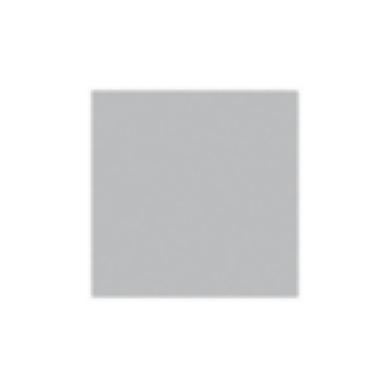

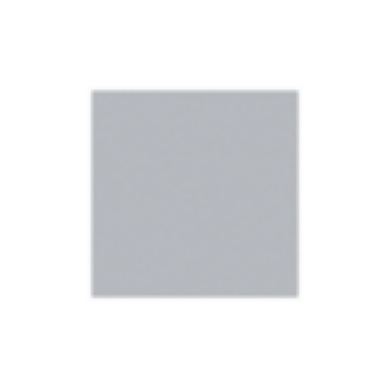

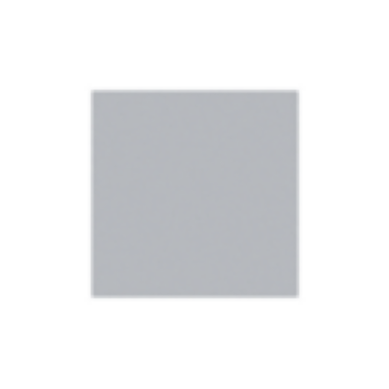

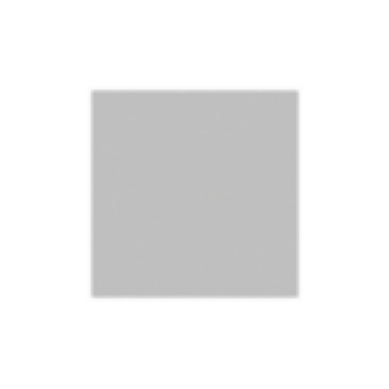

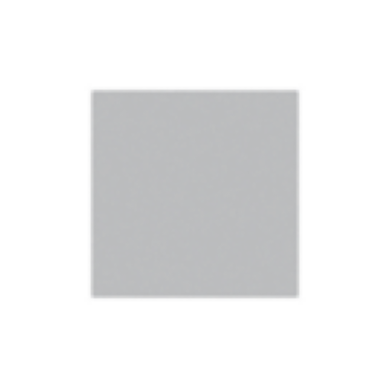

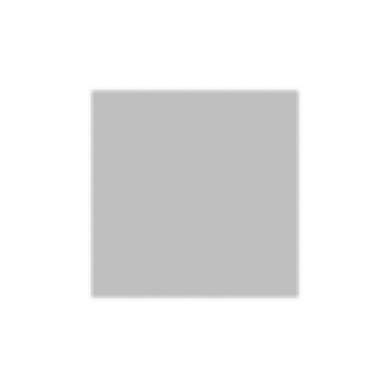

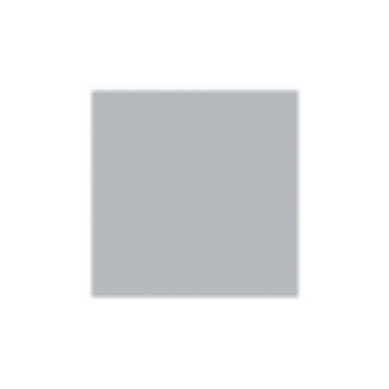

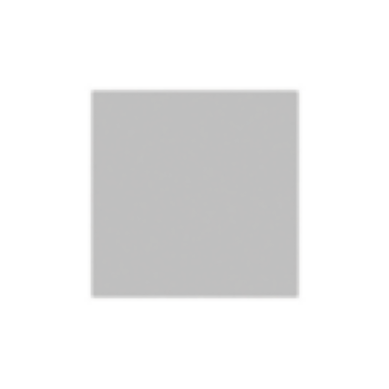

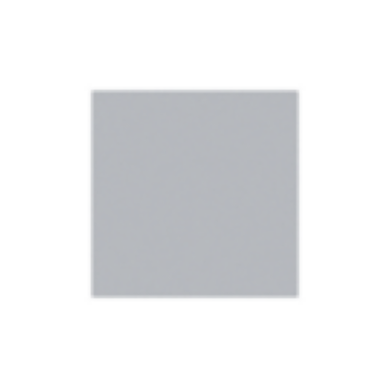

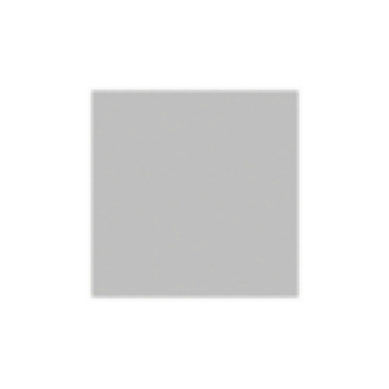

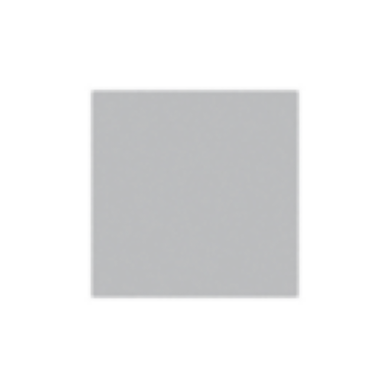

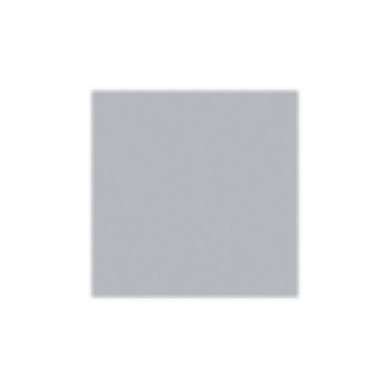

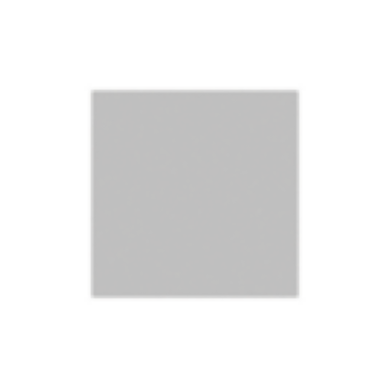

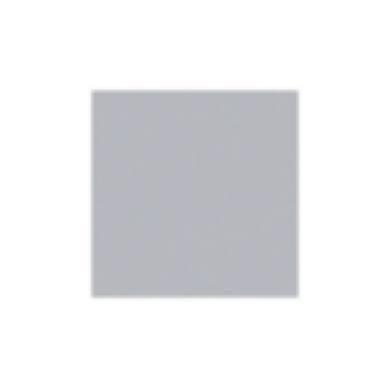

In [5]:


processed_images = {}   # Dictionary to store processed images

for name in os.listdir(img_path):
    if name.lower().endswith((".jpg", ".png", ".jpeg")):
        # Read the raw image
        img = Image.open(os.path.join(img_path, name))

        # Step 1: Crop (Removing margins to focus on the central color area)
        w, h = img.size
        crop_img = img.crop((50, 50, w - 50, h - 50))

        # Step 2: Gaussian Blur (Reducing high-frequency noise)
        arr = np.array(crop_img)
        blurred_arr = ndimage.gaussian_filter(arr, sigma=3)

        # Step 3: Resize (Standardizing dimensions to 128x128)
        final_img = Image.fromarray(blurred_arr).resize((128, 128))

        # Save processed image to dictionary
        processed_images[name] = final_img

        # Display the preprocessed output
        plt.imshow(final_img)
        plt.axis("off")
        plt.show()

## ==========================================
# Part 3: Image Classification Using K-Means
# ==========================================

Image Cluster Assignments:
1.png → Cluster 0
10.png → Cluster 2
11.png → Cluster 0
12.png → Cluster 1
13.png → Cluster 1
14.png → Cluster 2
15.png → Cluster 1
16.png → Cluster 2
17.png → Cluster 0
18.png → Cluster 1
19.png → Cluster 0
2.png → Cluster 0
20.png → Cluster 0
21.png → Cluster 0
22.png → Cluster 1
23.png → Cluster 0
24.png → Cluster 2
25.png → Cluster 0
26.png → Cluster 1
27.png → Cluster 0
28.png → Cluster 1
29.png → Cluster 2
3.png → Cluster 0
30.png → Cluster 2
31.png → Cluster 0
32.png → Cluster 2
33.png → Cluster 1
34.png → Cluster 1
35.png → Cluster 2
36.png → Cluster 1
37.png → Cluster 1
38.png → Cluster 2
39.png → Cluster 2
4.png → Cluster 0
40.png → Cluster 1
41.png → Cluster 2
42.png → Cluster 0
43.png → Cluster 1
44.png → Cluster 0
45.png → Cluster 0
46.png → Cluster 2
47.png → Cluster 2
48.png → Cluster 2
49.png → Cluster 1
5.png → Cluster 0
50.png → Cluster 1
51.png → Cluster 2
52.png → Cluster 0
53.png → Cluster 2
54.png → Cluster 0
55.png → Cluster 2
56.png → 

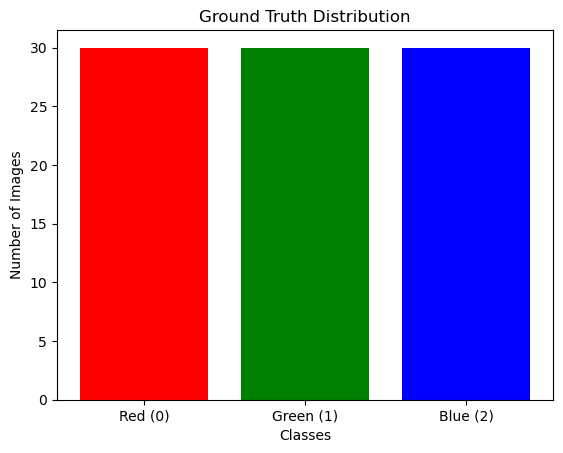

Confusion Matrix:
 [[30  0  0]
 [ 0 30  0]
 [ 0  0 30]]
Cluster Mapping: [0 1 2]
Accuracy: 1.0
All images successfully classified and saved.


In [6]:


K = 3

# 1) Feature extraction: Convert processed images to feature vectors (mean RGB values)
features = []
img_names_processed = list(processed_images.keys())

for name in img_names_processed:
    arr = np.array(processed_images[name])   # Convert PIL Image to NumPy array
    mean_rgb = arr.mean(axis=(0, 1))         # Compute mean RGB across all pixels
    features.append(mean_rgb)

features = np.array(features)   # shape: (N, 3)

# 2) Initialize cluster centroids randomly
np.random.seed(0)
centroids = features[np.random.choice(len(features), K, replace=False)]

# 3) Run K-Means iteration (Assignment + Update)
for _ in range(20):
    # Assignment step: Assign each image to the nearest cluster centroid
    distances = np.linalg.norm(features[:, None] - centroids[None, :], axis=2)
    labels_kmeans = distances.argmin(axis=1)

    # Update step: Recalculate centroids based on mean of cluster members
    for k in range(K):
        centroids[k] = features[labels_kmeans == k].mean(axis=0)
# Print cluster assignments for each image
print("Image Cluster Assignments:")
for name, lbl in zip(img_names_processed, labels_kmeans):
    print(name, "→ Cluster", lbl)

# Count and display number of images in each cluster
for k in range(K):
    count = np.sum(labels_kmeans == k)
    print(f"Number of images in Cluster {k} = {count}")

# Extract and visualize ground truth distribution
true_labels = np.array(list(labels.values()))
count_red   = np.sum(true_labels == 0)
count_green = np.sum(true_labels == 1)
count_blue  = np.sum(true_labels == 2)

print("Ground Truth Count - RED   :", count_red)
print("Ground Truth Count - GREEN :", count_green)
print("Ground Truth Count - BLUE  :", count_blue)        

classes = ["Red (0)", "Green (1)", "Blue (2)"]
counts  = [count_red, count_green, count_blue]

plt.bar(classes, counts, color=["red", "green", "blue"])
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Ground Truth Distribution")
plt.show()

# -----------------------------------------
# Accuracy assessment and cluster mapping
# -----------------------------------------
# Align ground truth labels with processed image names (standardizing to .jpg in lookup)
true_labels_aligned = np.array([
    labels[name.split('.')[0] + ".jpg"]
    for name in img_names_processed
])

# Create a confusion matrix to find the optimal mapping
# confusion[k][c] represents the count of images in cluster k belonging to class c
confusion = np.zeros((K, 3), dtype=int)
for kmeans_lbl, true_lbl in zip(labels_kmeans, true_labels_aligned):
    confusion[kmeans_lbl][true_lbl] += 1

# Map each cluster to the true class that has the highest representation
cluster_map = confusion.argmax(axis=1)

# Convert K-Means clusters to predicted labels using the mapping
predicted_labels = np.array([cluster_map[c] for c in labels_kmeans])

# Calculate final classification accuracy
accuracy = np.mean(predicted_labels == true_labels_aligned)

print("Confusion Matrix:\n", confusion)
print("Cluster Mapping:", cluster_map)
print("Accuracy:", accuracy)

# -----------------------------------------
# Save classified images to separate folders
# -----------------------------------------
output_base = "cluster_output"
class_names = ["red", "green", "blue"]

# Create output directories if they do not exist
for cname in class_names:
    os.makedirs(os.path.join(output_base, cname), exist_ok=True)

# Save images to their respective folders
for name, pred_label in zip(img_names_processed, predicted_labels):
    if name not in processed_images:
        print(f"Warning: {name} not found in processed_images")
        continue

    img = processed_images[name]
    folder = class_names[pred_label]
    save_path = os.path.join(output_base, folder, name)
    img.save(save_path)

print("All images successfully classified and saved.")

## ==========================================
# Part 4: Understanding Optimizers
# ==========================================

In [7]:


# 1) Demonstrating the optimization process with a simplified 3-class dataset
toy_data = np.array([
    [255, 0, 0],     # Red
    [250, 10, 5],
    [0, 255, 0],     # Green
    [5, 240, 10],
    [0, 0, 255],     # Blue
    [10, 5, 250]
])

toy_K = 3
np.random.seed(0)

# Initialize centroids
toy_centroids = toy_data[np.random.choice(len(toy_data), toy_K, replace=False)]

def compute_inertia(data, centroids, labels):
    inertia = 0
    for i in range(len(data)):
        inertia += np.sum((data[i] - centroids[labels[i]])**2)
    return inertia

print("\n--- Demonstrating K-Means Optimization Process ---")
for step in range(5):
    # Assignment Step
    distances = np.linalg.norm(toy_data[:, None] - toy_centroids[None, :], axis=2)
    toy_labels = distances.argmin(axis=1)

    # Calculate Inertia
    current_inertia = compute_inertia(toy_data, toy_centroids, toy_labels)

    print(f"\nStep {step + 1}")
    print("Centroids:\n", toy_centroids)
    print("Labels Assigned:", toy_labels)
    print("Current Inertia (Error):", current_inertia)

    # Update Step: Recalculate centroids
    new_centroids = []
    for k in range(toy_K):
        points = toy_data[toy_labels == k]
        new_centroids.append(points.mean(axis=0))
    toy_centroids = np.array(new_centroids)

# 2) Demonstrating that K-Means is a Minimization algorithm (WCSS / Inertia minimization)
print("\n--- Demonstrating Inertia Minimization Trend ---")
toy_centroids_min = toy_data[np.random.choice(len(toy_data), toy_K, replace=False)]

def get_inertia(data, centroids, labels):
    return np.sum((data - centroids[labels])**2)

for step in range(6):
    distances = np.linalg.norm(toy_data[:, None] - toy_centroids_min[None, :], axis=2)
    toy_labels = distances.argmin(axis=1)

    J = get_inertia(toy_data, toy_centroids_min, toy_labels)
    print(f"Iteration Step {step + 1} - WCSS / Inertia = {J}")

    new_centroids = []
    for k in range(toy_K):
        cluster_points = toy_data[toy_labels == k]
        new_centroids.append(cluster_points.mean(axis=0))
    toy_centroids_min = np.array(new_centroids)



--- Demonstrating K-Means Optimization Process ---

Step 1
Centroids:
 [[ 10   5 250]
 [  0 255   0]
 [250  10   5]]
Labels Assigned: [2 2 1 1 0 0]
Current Inertia (Error): 650

Step 2
Centroids:
 [[  5.    2.5 252.5]
 [  2.5 247.5   5. ]
 [252.5   5.    2.5]]
Labels Assigned: [2 2 1 1 0 0]
Current Inertia (Error): 325.0

Step 3
Centroids:
 [[  5.    2.5 252.5]
 [  2.5 247.5   5. ]
 [252.5   5.    2.5]]
Labels Assigned: [2 2 1 1 0 0]
Current Inertia (Error): 325.0

Step 4
Centroids:
 [[  5.    2.5 252.5]
 [  2.5 247.5   5. ]
 [252.5   5.    2.5]]
Labels Assigned: [2 2 1 1 0 0]
Current Inertia (Error): 325.0

Step 5
Centroids:
 [[  5.    2.5 252.5]
 [  2.5 247.5   5. ]
 [252.5   5.    2.5]]
Labels Assigned: [2 2 1 1 0 0]
Current Inertia (Error): 325.0

--- Demonstrating Inertia Minimization Trend ---
Iteration Step 1 - WCSS / Inertia = 650
Iteration Step 2 - WCSS / Inertia = 325.0
Iteration Step 3 - WCSS / Inertia = 325.0
Iteration Step 4 - WCSS / Inertia = 325.0
Iteration Step 5 - WCS